# Plot EMG

Python/matplotlib equivalent of `plot_emg.m`. Builds `trial_meta` from the CSV + metadata JSON pipeline (one row per trial, `EMG1k` as a `(numSamples, numChannels)` array per trial), then plots either a single trial or the mean across trials for a given task.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Settings

In [8]:
DATA_PATH = "sample_set/csv/P1_S12_EMG1kHz.csv"
TRIAL_META_PATH = "sample_set/meta/P1_S12_meta.json"
CH_META_PATH = "sample_set/meta/P1_metadata.json"
TASKS_PATH = "sample_set/movements.json"

FS = 1000            # sampling rate (Hz)
TRIAL_ID = 53         # which trial to plot (ignored when PLOT_MEAN = True)
TASK_NUMBER = 1       # task to average (used when PLOT_MEAN = True)
PLOT_MEAN = False     # False = single trial | True = mean across task trials

## Load metadata and assemble `trial_meta`

Same pipeline as the CSV-to-dataframe notebook: reshape the long-format EMG csv into one `(numSamples, numChannels)` array per trial, then attach task names and pull an ordered channel-name list.

In [10]:
def build_trial_meta(data_path, trial_meta_path, ch_meta_path, tasks_path):
    """Load CSV + metadata JSONs and assemble the trial-level DataFrame
    with EMG1k stored as a (numSamples, numChannels) array per trial."""

    # trial-level metadata (one row per trial)
    trial_meta = pd.read_json(trial_meta_path)

    # reshape EMG csv: group by TrialID -> (numSamples, numChannels) array per trial
    emg_raw = pd.read_csv(data_path)
    channel_cols = [c for c in emg_raw.columns if c.startswith('EMG1k_')]
    emg_arrays = {
        tid: group[channel_cols].to_numpy()
        for tid, group in emg_raw.groupby('TrialID')
    }
    trial_meta['EMG1k'] = trial_meta['TrialID'].map(emg_arrays)

    # task names
    tasks = pd.read_json(tasks_path)
    tasks = tasks.rename(columns={'movementNumber': 'TaskNumber', 'movementName': 'TaskName'})
    tasks['TaskNumber'] = tasks['TaskNumber'].astype(int)
    trial_meta['TaskNumber'] = trial_meta['TaskNumber'].astype(int)
    trial_meta = trial_meta.merge(tasks[['TaskNumber', 'TaskName']], on='TaskNumber', how='left')

    # channel names, ordered by channel number
    channels = pd.read_json(ch_meta_path)
    channel_names = channels.sort_values('channelNumber')['channelName'].tolist()

    return trial_meta, channel_names


trial_meta, channel_names = build_trial_meta(DATA_PATH, TRIAL_META_PATH, CH_META_PATH, TASKS_PATH)

print(f"Channels : {', '.join(channel_names)}")
print(f"Trials   : {len(trial_meta)} | Tasks: {sorted(trial_meta['TaskNumber'].unique())}")
trial_meta.head()

Channels : EPL, EDC, FPL, FDP Index, Median RPNI, Ulnar 1 RPNI, Ulnar 2 RPNI, FCR
Trials   : 100 | Tasks: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(18), np.int64(23), np.int64(25), np.int64(30), np.int64(31), np.int64(32)]


,TrialID,TaskNumber,TrialNumber,RestTime,HoldTime,EMG1k,TaskName
0,1,1,1,4000,4000,"[[-0.5, 7.25, 4.25, -3.25, -3.5, 2.5, -6.5, -4...",rest
1,2,1,2,4000,4000,"[[73.25, 6.0, 3.0, 4.0, 3.75, -3.0, 3.75, -6.0...",rest
2,3,1,3,4000,4000,"[[207.5, 0.5, 1.0, 7.0, -3.5, -4.25, -6.0, 3.7...",rest
3,4,1,4,4000,4000,"[[-292.75, -5.75, -4.5, 1.25, -4.5, -3.25, -5....",rest
4,5,1,5,4000,4000,"[[204.5, -2.25, -4.75, 3.5, -3.0, 2.5, -0.75, ...",rest


## Plotting functions

In [11]:
def plot_single_trial(trial_meta, trial_id, channel_names, fs=FS):
    """Plot every channel for a single trial as a stacked grid of subplots."""
    row = trial_meta.loc[trial_meta['TrialID'] == trial_id].iloc[0]
    emg = row['EMG1k']  # (numSamples, numChannels)
    n_samples, n_ch = emg.shape
    time = np.arange(n_samples) / fs
    title = (
        f"EMG — Trial {trial_id} "
        f"(Task {row['TaskNumber']}: {row['TaskName']}, Rep {row['TrialNumber']})"
    )

    fig, axes = plt.subplots(n_ch, 1, figsize=(9, 11), sharex=True)
    for ci, ax in enumerate(axes):
        ax.plot(time, emg[:, ci], linewidth=0.6)
        ax.set_xlim(0, time.max())
        ax.grid(True, color='0.85')
        ax.set_ylabel(channel_names[ci], fontsize=8, rotation=0, ha='right', va='center')
    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(title, fontsize=13, fontweight='bold')
    fig.tight_layout()
    return fig


def plot_mean_task(trial_meta, task_number, channel_names, fs=FS):
    """Plot the mean EMG trace (averaged across trials) for a given task."""
    subset = trial_meta.loc[trial_meta['TaskNumber'] == task_number]
    n_trials = len(subset)
    arrays = np.stack(subset['EMG1k'].to_list())  # (n_trials, numSamples, numChannels)
    emg_mean = arrays.mean(axis=0)
    n_samples, n_ch = emg_mean.shape
    time = np.arange(n_samples) / fs
    task_name = subset['TaskName'].iloc[0]
    title = f"Mean EMG — Task {task_number}: {task_name} (n={n_trials} trials)"

    fig, axes = plt.subplots(n_ch, 1, figsize=(9, 11), sharex=True)
    for ci, ax in enumerate(axes):
        ax.plot(time, emg_mean[:, ci], linewidth=0.6)
        ax.set_xlim(0, time.max())
        ax.grid(True, color='0.85')
        ax.set_ylabel(channel_names[ci], fontsize=8, rotation=0, ha='right', va='center')
    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(title, fontsize=13, fontweight='bold')
    fig.tight_layout()
    return fig

## Plot

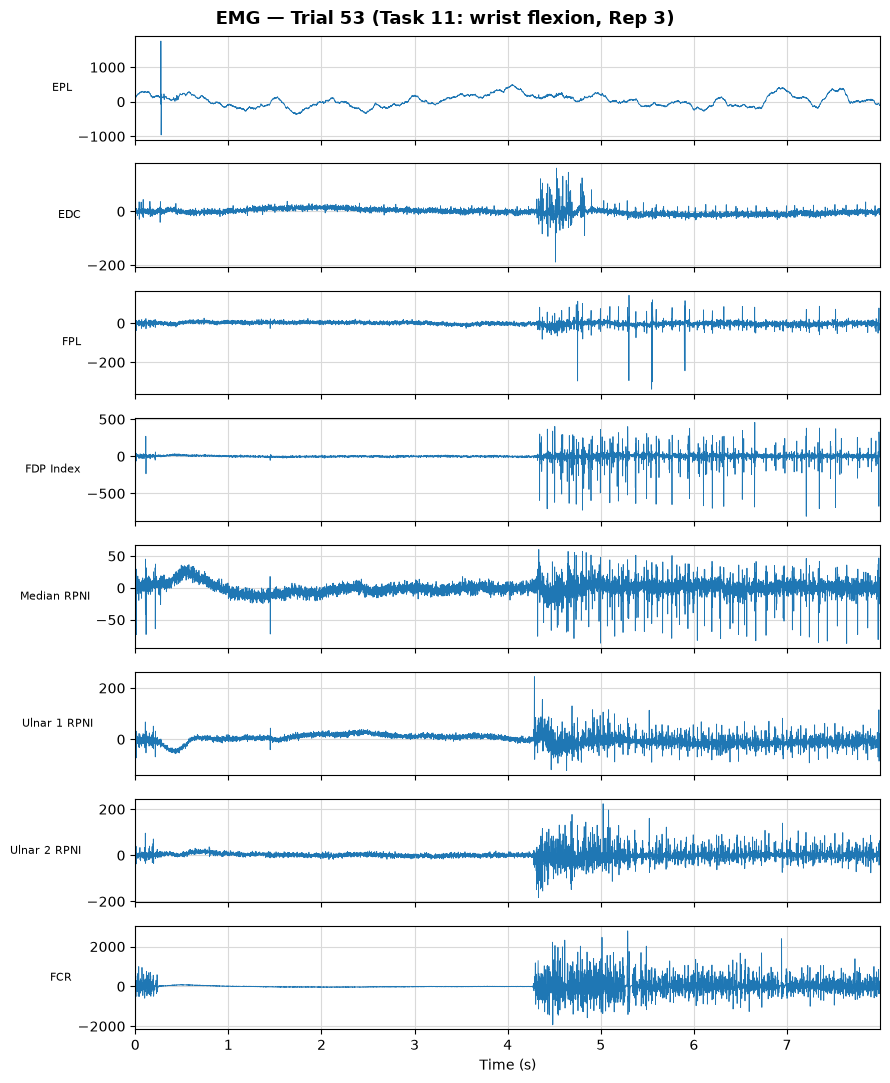

In [12]:
if PLOT_MEAN:
    fig = plot_mean_task(trial_meta, TASK_NUMBER, channel_names)
else:
    fig = plot_single_trial(trial_meta, TRIAL_ID, channel_names)